# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [2]:
%pip install iso3166

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [3]:
%pip install --upgrade plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Import Statements

In [4]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [5]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [6]:
df_data = pd.read_csv(r'D:\PycharmProjects\day-99-Space_mission_project\mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [7]:
df_data.shape

(4324, 9)

In [8]:
df_data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

In [9]:
df_data.isnull().values.any()

True

## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [10]:
df_data.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64

In [11]:
df_data.duplicated().sum()

0

In [12]:
df_data.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], inplace=True)

In [13]:
df_data.columns

Index(['Organisation', 'Location', 'Date', 'Detail', 'Rocket_Status', 'Price',
       'Mission_Status'],
      dtype='object')

## Descriptive Statistics

In [14]:
df_data.describe()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,4324,4324,4324,4324,4324,964,4324
unique,56,137,4319,4278,2,56,4
top,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Wed Nov 05, 2008 00:15 UTC",Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,450.0,Success
freq,1777,235,2,6,3534,136,3879


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [15]:
launches_by_org=df_data['Organisation'].value_counts()
launches_by_org.head(10)

Organisation
RVSN USSR           1777
Arianespace          279
CASC                 251
General Dynamics     251
NASA                 203
VKS RF               201
US Air Force         161
ULA                  140
Boeing               136
Martin Marietta      114
Name: count, dtype: int64

In [16]:
fig=px.bar(
    launches_by_org.head(10),
    x=launches_by_org.head(10).values,
    y=launches_by_org.head(10).index,
    orientation='h',
    title='Top 10 Organisations by Number of Space Launches',
    labels={'x': 'Number of Launches', 'y': 'Organization'}
)

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

In [17]:
rocket_status=df_data['Rocket_Status'].value_counts()
rocket_status

Rocket_Status
StatusRetired    3534
StatusActive      790
Name: count, dtype: int64

In [18]:
fig=px.pie(
    values=rocket_status.values,
    names=rocket_status.index,
    title='Active vs Retired Rockets'
)
fig.show()

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [19]:
mission_status=df_data['Mission_Status'].value_counts()
mission_status

Mission_Status
Success              3879
Failure               339
Partial Failure       102
Prelaunch Failure       4
Name: count, dtype: int64

In [20]:
fig=px.pie(
    values=mission_status.values,
    names=mission_status.index,
    title='Distribution of Misssion Status'
)
fig.show()

# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

In [21]:
price_data=df_data['Price'].dropna()
price_data.describe()

count       964
unique       56
top       450.0
freq        136
Name: Price, dtype: object

In [22]:
fig=px.histogram(
    price_data,
    x='Price' if isinstance(price_data, pd.DataFrame) else price_data,
    nbins=50,
    title='Distribution of Rocket Launch Prices',
    labels={'value':'Price (USD millions)'}
)
fig.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [23]:
df_data['Country']=df_data['Location'].str.split(',').str[-1].str.strip()

country_replacements={
    'Russia': 'Russian Federation',
    'New Mexico': 'USA',
    'Yellow Sea': 'China',
    'Shahrud Missile Test Site': 'Iran',
    'Pacific Missile Range Facility': 'USA',
    'Barents Sea': 'Russian Federation',
    'Gran Canaria': 'USA'
}
df_data['Country']=df_data['Country'].replace(country_replacements)
df_data['Country'].value_counts().head(20)

Country
Russian Federation    1398
USA                   1351
Kazakhstan             701
France                 303
China                  269
Japan                  126
India                   76
Pacific Ocean           36
Iran                    14
New Zealand             13
Israel                  11
Kenya                    9
Australia                6
North Korea              5
South Korea              3
Brazil                   3
Name: count, dtype: int64

In [24]:
country_counts=df_data['Country'].value_counts().reset_index()
country_counts.columns=['Country','Launches']

country_codes=[]
for country in country_counts['Country']:
    try:
        country_codes.append(countries.get(country).alpha3)
    except:
        country_codes.append(None)

country_counts['Code']=country_codes
country_counts.head()

,Country,Launches,Code
0,Russian Federation,1398,RUS
1,USA,1351,USA
2,Kazakhstan,701,KAZ
3,France,303,FRA
4,China,269,CHN


In [25]:
fig = px.choropleth(
    country_counts,
    locations='Code',
    color='Launches',
    hover_name='Country',
    color_continuous_scale='matter',
    title='Number of Space Launches by Country'
)

fig.show()

# Use a Choropleth Map to Show the Number of Failures by Country


In [26]:
failure_data=df_data[df_data['Mission_Status']=='Failure']

failure_counts=failure_data['Country'].value_counts().reset_index()
failure_counts.columns = ['Country', 'Failures']

country_code_map={
    'USA':'USA',
    'Kazakhstan':'KAZ',
    'Russian Federation':'RUS',
    'China':'CHN',
    'France':'FRA',
    'India':'IND',
    'Japan':'JPN',
    'Iran':'IRN',
    'Israel':'ISR',
    'New Zealand':'NZL',
    'Australia':'AUS',
    'Brazil':'BRA',
    'Canada':'CAN',
    'Germany':'DEU',
    'Italy':'ITA',
    'United Kingdom':'GBR',
    'Ukraine':'UKR',
    'North Korea':'PRK',
    'South Korea':'KOR',
    'Spain':'ESP'
}

failure_counts['Code'] = failure_counts['Country'].map(country_code_map)

failure_counts.head()

,Country,Failures,Code
0,USA,129,USA
1,Kazakhstan,72,KAZ
2,Russian Federation,63,RUS
3,China,19,CHN
4,France,13,FRA


In [27]:
fig = px.choropleth(
    failure_counts,
    locations='Code',
    color='Failures',
    hover_name='Country',
    color_continuous_scale='Reds',
    title='Number of Mission Failures by Country'
)

fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

In [28]:
sunburst_data=(
    df_data
    .groupby(['Country','Organisation','Mission_Status'])
    .size()
    .reset_index(name='Count')
)

sunburst_data.head()

,Country,Organisation,Mission_Status,Count
0,Australia,AMBA,Success,1
1,Australia,CECLES,Failure,2
2,Australia,CECLES,Success,1
3,Australia,RAE,Failure,1
4,Australia,RAE,Success,1


In [29]:
fig=px.sunburst(
    sunburst_data,
    path=['Country','Organisation','Mission_Status'],
    values='Count',
    title='Space Missions by country,organisation and mission status'
)
fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [30]:
df_data['Price'] = (
    df_data['Price']
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .astype(float)
)

money_by_org=(
    df_data
    .dropna(subset=['Price'])
    .groupby('Organisation')['Price']
    .sum()
    .sort_values(ascending=False)
)
money_by_org.head(10)

Organisation
NASA           76,280.00
Arianespace    16,345.00
ULA            14,798.00
RVSN USSR      10,000.00
CASC            6,340.26
SpaceX          5,444.00
Northrop        3,930.00
MHI             3,532.50
ISRO            2,177.00
US Air Force    1,550.92
Name: Price, dtype: float64

In [31]:
fig=px.bar(
    money_by_org.head(10),
    x=money_by_org.head(10).values,
    y=money_by_org.head(10).index,
    orientation='h',
    title='Top 10 Organisations by Total Launch Spending',
    labels={'x':'Total spending (USD millions)', 'y': 'Organisation'}
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

# Analyse the Amount of Money Spent by Organisation per Launch

In [32]:
avg_price_by_org=(
    df_data
    .dropna(subset=['Price'])
    .groupby('Organisation')['Price']
    .mean()
    .sort_values(ascending=False)
)
avg_price_by_org.head(10)

Organisation
RVSN USSR         5,000.00
NASA                511.95
Boeing              177.29
Arianespace         170.26
ULA                 151.00
ILS                 101.54
MHI                  95.47
Martin Marietta      80.16
US Air Force         59.65
JAXA                 56.00
Name: Price, dtype: float64

In [33]:
fig=px.bar(
    avg_price_by_org.head(10),
    x=avg_price_by_org.head(10).values,
    y=avg_price_by_org.head(10).index,
    orientation='h',
    title='Top 10 Organisations by Average Launch Cost',
    labels={'x': 'Average Price (USD millions)', 'y': 'Organisation'}
)

fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

# Chart the Number of Launches per Year

In [34]:
df_data['Date']=pd.to_datetime(
    df_data['Date'],
    format='mixed',
    utc=True
)
df_data['Year'] = df_data['Date'].dt.year
launches_per_year = df_data['Year'].value_counts().sort_index()
launches_per_year.head()

Year
1957     3
1958    28
1959    20
1960    39
1961    52
Name: count, dtype: int64

In [35]:
fig=px.line(
    x=launches_per_year.index,
    y=launches_per_year.values,
    markers=True,
    title='Number of space launches per year',
    labels={'x':'Year','y':'Number of launches'}
)
fig.show()

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart. 

In [36]:
monthly_launches=(df_data
                 .set_index("Date")
                 .resample("ME")
                 .size()
                 )
monthly_launches.head()

Date
1957-10-31 00:00:00+00:00    1
1957-11-30 00:00:00+00:00    1
1957-12-31 00:00:00+00:00    1
1958-01-31 00:00:00+00:00    0
1958-02-28 00:00:00+00:00    2
Freq: ME, dtype: int64

In [37]:
rolling_avg=monthly_launches.rolling(12).mean()

fig=px.line(
    x=monthly_launches.index,
    y=monthly_launches.values,
    title='Monthly Space Launches with 12-Month Rolling Average',
    labels={'x':'Date','y':'Number of Launches'}
)

fig.add_scatter(
    x=rolling_avg.index,
    y=rolling_avg.values,
    mode='lines',
    name='12-Month Rolling Average'    
)
fig.show()

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [38]:
df_data['Month']=df_data['Date'].dt.month
monthly_counts=df_data['Month'].value_counts().sort_index()
monthly_counts

Month
1     268
2     336
3     353
4     383
5     326
6     402
7     351
8     373
9     365
10    381
11    336
12    450
Name: count, dtype: int64

In [39]:
month_names={
    1: 'January',2: 'Febuary',3: 'March',4: 'April',5: 'May',6: 'June',
    7: 'July',8: 'August',9: 'September',10: 'October',11: 'November',12: 'December'
}
month_data=monthly_counts.rename(index=month_names)

fig=px.bar(
    x=month_data.index,
    y=month_data.values,
    title='Number of space launches by month',
    labels={'x':'Month','y':'Number of launches'}
)
fig.show()

# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time. 

In [40]:
avg_price_year=(
    df_data
    .dropna(subset=['Price'])
    .groupby('Year')['Price']
    .mean()
)
avg_price_year.head()

Year
1964    63.23
1965    63.23
1966    59.00
1967   196.62
1968   279.20
Name: Price, dtype: float64

In [41]:
fig=px.line(
    x=avg_price_year.index,
    y=avg_price_year.values,
    markers=True,
    title='Average rocket launch price over time',
    labels={'x':'Year','y':'Average Price (USD millions'}
)
fig.show()

# Chart the Number of Launches over Time by the Top 10 Organisations. 

How has the dominance of launches changed over time between the different players? 

In [42]:
top_10_orgs=df_data['Organisation'].value_counts().head(10).index

top_org_data=df_data[
    df_data['Organisation'].isin(top_10_orgs)
]

year_org_counts=(
    top_org_data
    .groupby(['Year','Organisation'])
    .size()
    .reset_index(name='Launches')
)
year_org_counts.head()

,Year,Organisation,Launches
0,1957,RVSN USSR,2
1,1958,NASA,2
2,1958,RVSN USSR,5
3,1958,US Air Force,2
4,1959,General Dynamics,1


In [43]:
fig=px.line(
    year_org_counts,
    x='Year',
    y='Launches',
    color='Organisation',
    title='Launches over time by top 10 organisation',
    labels={'Launches':'Number of launches'}
)
fig.show()

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991. 

In [44]:
cold_war=df_data[df_data['Year']<=1991].copy()

ussr_countries=[
    'Russian Federation',
    'Kazakhstan',
    'Ukraine',
    'Belarus',
    'Azerbaijan',
    'Uzbekistan'
]

cold_war['Superpower']=np.where(
    cold_war['Country'].isin(ussr_countries),
    'USSR',
    np.where(
        cold_war['Country']=='USA',
        'USA',
        'Other'
    )
)
cold_war=cold_war[
cold_war['Superpower'].isin(['USA','USSR'])
]

cold_war['Superpower'].value_counts()

Superpower
USSR    1770
USA      662
Name: count, dtype: int64

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches. 

In [45]:
superpower_launches=cold_war['Superpower'].value_counts()
superpower_launches

Superpower
USSR    1770
USA      662
Name: count, dtype: int64

In [46]:
fig=px.pie(
    values=superpower_launches.values,
    names=superpower_launches.index,
    title='USA vs USSR: Total space launches during the cold war'
)
fig.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [47]:
yearly_superpower=(
    cold_war
    .groupby(['Year','Superpower'])
    .size()
    .reset_index(name='Launches')
)
yearly_superpower.head()

,Year,Superpower,Launches
0,1957,USA,1
1,1957,USSR,2
2,1958,USA,23
3,1958,USSR,5
4,1959,USA,16


In [48]:
fig=px.line(
    yearly_superpower,
    x='Year',
    y='Launches',
    color='Superpower',
    markers=True,
    title='USA vs USSR Space Launches Year-on-Year',
    labels={'Launches': 'Number of Launches'}
)

fig.show()

## Chart the Total Number of Mission Failures Year on Year.

In [49]:
failures_by_year=(
    cold_war[cold_war['Mission_Status']=='Failure']
    .groupby('Year')
    .size()
)
failures_by_year.head()

Year
1957     1
1958    20
1959     9
1960    20
1961    17
dtype: int64

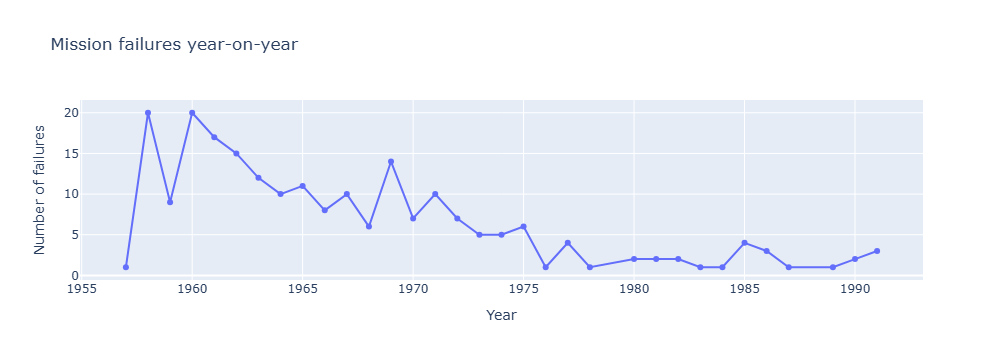

In [50]:
fig=px.line(
    x=failures_by_year.index,
    y=failures_by_year.values,
    markers=True,
    title='Mission failures year-on-year',
    labels={'x':'Year','y':'Number of failures'}
)
fig.show()

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time? 

In [51]:
yearly_total=cold_war.groupby('Year').size()

yearly_failures=(
    cold_war[cold_war['Mission_Status']=='Failure']
    .groupby('Year')
    .size()
)

failure_percentage=(
    yearly_failures
    .div(yearly_total)
    .fillna(0)
    *100
)
failure_percentage.head()

Year
1957   33.33
1958   71.43
1959   45.00
1960   51.28
1961   32.69
dtype: float64

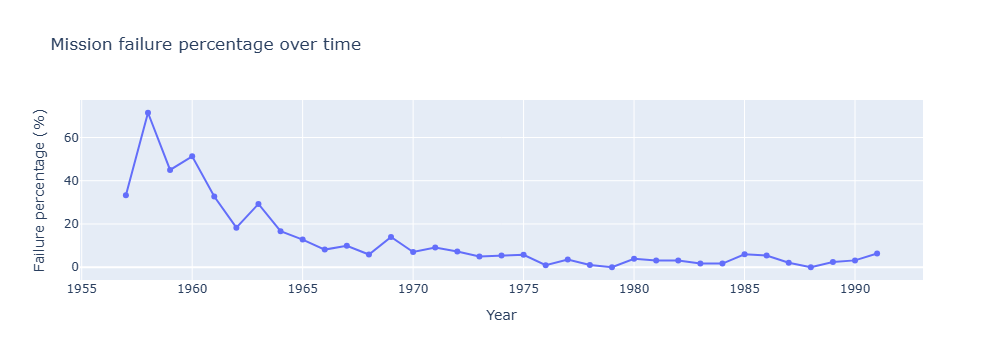

In [53]:
fig=px.line(
    x=failure_percentage.index,
    y=failure_percentage.values,
    markers=True,
    title='Mission failure percentage over time',
    labels={'x':'Year','y':'Failure percentage (%)'}
)
fig.show()

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches? 

In [54]:
country_year=(
    cold_war
    .groupby(['Year','Superpower'])
    .size()
    .unstack(fill_value=0)
)
country_year['Leader']=country_year.idxmax(axis=1)
country_year.head(15)

Superpower,USA,USSR,Leader
Year,,,
1957,1,2,USSR
1958,23,5,USA
1959,16,4,USA
1960,30,9,USA
1961,43,9,USA
1962,60,22,USA
1963,17,24,USSR
1964,24,36,USSR
1965,33,53,USSR


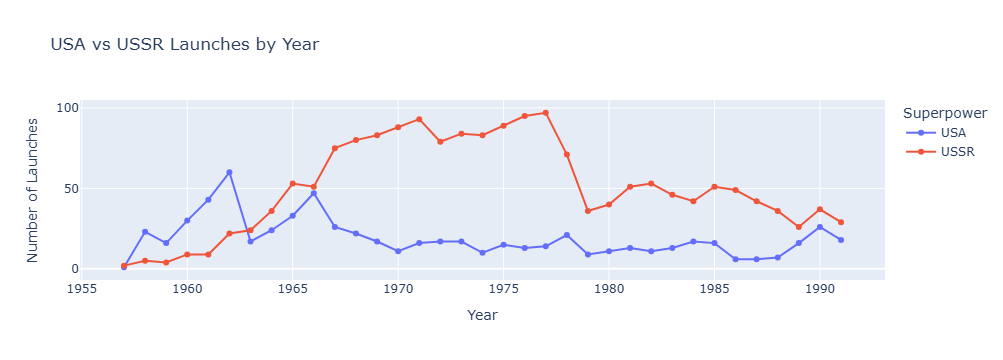

In [55]:
fig=px.line(
    country_year[['USA', 'USSR']],
    markers=True,
    title='USA vs USSR Launches by Year',
    labels={'value': 'Number of Launches', 'Year': 'Year'}
)

fig.show()

In [57]:
#lead based on successful launches
successful=cold_war[cold_war['Mission_Status']=='Success']

successful_by_year=(
    successful
    .groupby(['Year','Superpower'])
    .size()
    .unstack(fill_value=0)
)

successful_by_year['Leader']=successful_by_year.idxmax(axis=1)

successful_by_year.head(15)

Superpower,USA,USSR,Leader
Year,,,
1957,0,2,USSR
1958,5,1,USA
1959,6,2,USA
1960,16,3,USA
1961,27,5,USA
1962,50,15,USA
1963,13,16,USSR
1964,19,29,USSR
1965,26,47,USSR


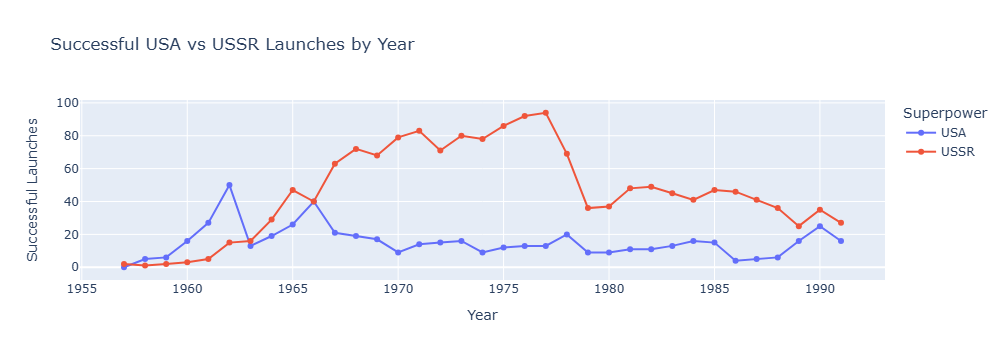

In [60]:
fig=px.line(
    successful_by_year[['USA', 'USSR']],
    markers=True,
    title='Successful USA vs USSR Launches by Year',
    labels={'value': 'Successful Launches', 'Year': 'Year'}
)

fig.show()

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 

In [61]:
org_year=(
    df_data
    .groupby(['Year','Organisation'])
    .size()
    .reset_index(name='Launches')
)
top_org_each_year=(
    org_year
    .loc[org_year.groupby('Year')['Launches'].idxmax()]
    .sort_values("Year")
)
top_org_each_year.head()

,Year,Organisation,Launches
0,1957,RVSN USSR,2
6,1958,US Navy,12
10,1959,US Air Force,10
15,1960,US Air Force,21
19,1961,US Air Force,23


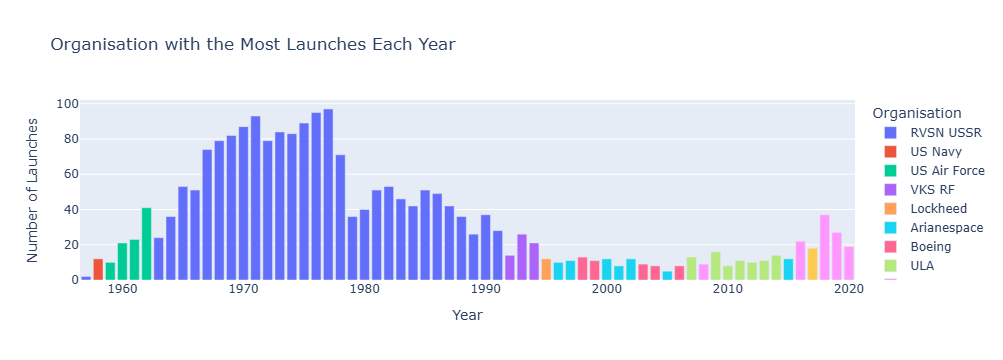

In [62]:
fig=px.bar(
    top_org_each_year,
    x='Year',
    y='Launches',
    color='Organisation',
    title='Organisation with the Most Launches Each Year',
    labels={'Launches': 'Number of Launches'}
)

fig.show()

In [63]:
years_to_check = list(range(1970, 1990)) + [2018, 2019, 2020]

top_org_each_year[
    top_org_each_year['Year'].isin(years_to_check)
]

,Year,Organisation,Launches
80,1970,RVSN USSR,87
93,1971,RVSN USSR,93
101,1972,RVSN USSR,79
108,1973,RVSN USSR,84
115,1974,RVSN USSR,83
125,1975,RVSN USSR,89
132,1976,RVSN USSR,95
139,1977,RVSN USSR,97
146,1978,RVSN USSR,71
153,1979,RVSN USSR,36
